In [1]:
import pandas as pd 
import numpy as np 
df = pd.read_csv("IPL_Auction/IPL_Auction_2025_Sold_Player.csv")
# df.isnull().sum()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         182 non-null    int64 
 1   Name               182 non-null    object
 2   Nationality        182 non-null    object
 3   BasePrices in Rs   182 non-null    object
 4   Winning Bid in Rs  182 non-null    object
 5   TeamName           182 non-null    object
 6   Capped/UnCapped    182 non-null    object
dtypes: int64(1), object(6)
memory usage: 10.1+ KB


,Unnamed: 0,Name,Nationality,BasePrices in Rs,Winning Bid in Rs,TeamName,Capped/UnCapped
count,182.000000,182,182,182,182,182,182
unique,NaN,182,2,7,59,10,2
top,NaN,Noor Ahmad,Indian,"30,00,000","30,00,000",Punjab Kings,Capped
freq,NaN,1,115,82,46,23,97
mean,90.500000,NaN,NaN,NaN,NaN,NaN,NaN
std,52.683014,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,45.250000,NaN,NaN,NaN,NaN,NaN,NaN
50%,90.500000,NaN,NaN,NaN,NaN,NaN,NaN
75%,135.750000,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
df

,Unnamed: 0,Name,Nationality,BasePrices in Rs,Winning Bid in Rs,TeamName,Capped/UnCapped
0,0,Noor Ahmad,Overseas,"2,00,00,000","10,00,00,000",Chennai Super Kings,Capped
1,1,Ravichandaran Ashwin,Indian,"2,00,00,000","9,75,00,000",Chennai Super Kings,Capped
2,2,Devon Conway,Overseas,"2,00,00,000","6,25,00,000",Chennai Super Kings,Capped
3,3,Syed Khaleel Ahmed,Indian,"2,00,00,000","4,80,00,000",Chennai Super Kings,Capped
4,4,Rachin Ravindra,Overseas,"1,50,00,000","4,00,00,000",Chennai Super Kings,Capped
...,...,...,...,...,...,...,...
177,177,Kamindu Mendis,Overseas,"75,00,000","75,00,000",Sunrisers Hyderabad,Capped
178,178,Zeeshan Ansari,Indian,"30,00,000","40,00,000",Sunrisers Hyderabad,Uncapped
179,179,Sachin Baby,Indian,"30,00,000","30,00,000",Sunrisers Hyderabad,Uncapped
180,180,Aniket Verma,Indian,"30,00,000","30,00,000",Sunrisers Hyderabad,Uncapped


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         182 non-null    int64 
 1   Name               182 non-null    object
 2   Nationality        182 non-null    object
 3   BasePrices in Rs   182 non-null    object
 4   Winning Bid in Rs  182 non-null    object
 5   TeamName           182 non-null    object
 6   Capped/UnCapped    182 non-null    object
dtypes: int64(1), object(6)
memory usage: 10.1+ KB


# ==========================================
# Standardize Auction Dataset Schema
# ==========================================

In [4]:
def load_auction_data(file_path, year):

    # Read CSV
    df = pd.read_csv(file_path)

    # Remove unwanted column
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

    # Skip 2013 (Price is in USD)
    if year == 2013:
        return None

    # Rename price column
    if "Price in rs" in df.columns:
        df.rename(columns={"Price in rs": "Winning Bid in Rs"}, inplace=True)

    # Clean Winning Bid column
    df["Winning Bid in Rs"] = (
        df["Winning Bid in Rs"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
        .astype("int64")
    )

    # Create missing columns
    if "Nationality" not in df.columns:
        df["Nationality"] = np.nan

    if "Role" not in df.columns:
        df["Role"] = np.nan

    # Add Auction Year
    df["Auction_Year"] = year

    # Keep only required columns
    df = df[
        [
            "Auction_Year",
            "Name",
            "Nationality",
            "Role",
            "Winning Bid in Rs",
            "TeamName",
        ]
    ]

    return df

# ==========================================
# 5. Load & Combine All Auction Datasets
# ==========================================

In [5]:
auction_files = {
    2013: "IPL_Auction/IPL_Auction_2013_Sold_Player.csv",
    2014: "IPL_Auction/IPL_Auction_2014_Sold_Player.csv",
    2015: "IPL_Auction/IPL_Auction_2015_Sold_Player.csv",
    2016: "IPL_Auction/IPL_Auction_2016_Sold_Player.csv",
    2017: "IPL_Auction/IPL_Auction_2017_Sold_Player.csv",
    2018: "IPL_Auction/IPL_Auction_2018_Sold_Player.csv",
    2019: "IPL_Auction/IPL_Auction_2019_Sold_Player.csv",
    2020: "IPL_Auction/IPL_Auction_2020_Sold_Player.csv",
    2021: "IPL_Auction/IPL_Auction_2021_Sold_Player.csv",
    2022: "IPL_Auction/IPL_Auction_2022_Sold_Player.csv",
    2023: "IPL_Auction/IPL_Auction_2023_Sold_Player.csv",
    2024: "IPL_Auction/IPL_Auction_2024_Sold_Player.csv",
    2025: "IPL_Auction/IPL_Auction_2025_Sold_Player.csv"
}

auction_dfs = []

for year, file in auction_files.items():

    df = load_auction_data(file, year)

    if df is not None:
        auction_dfs.append(df)

auction_df = pd.concat(auction_dfs, ignore_index=True)
auction_df["Auction_Year"].value_counts().sort_index()

Auction_Year
2014    154
2015     67
2016     94
2017     66
2018    169
2019     60
2020     62
2021     57
2022    204
2023     80
2024     72
2025    182
Name: count, dtype: int64

# ==========================================
# Data Validation
# ==========================================

In [6]:
auction_df.isnull().sum()

Auction_Year           0
Name                   0
Nationality          729
Role                 182
Winning Bid in Rs      0
TeamName               0
dtype: int64

In [7]:
auction_df["TeamName"].unique()

array(['Chennai Super Kings', 'Delhi Daredevils', 'Kings XI Punjab',
       'Kolkata Knight Riders', 'Mumbai Indians', 'Rajasthan Royals',
       ' Royal Challengers Bengaluru', ' Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiant', ' Chennai Super Kings',
       ' Kolkata Knight Riders', ' Mumbai Indians', ' Rajasthan Royals',
       ' Delhi Capitals', ' Kings XI Punjab', ' Punjab Kings',
       ' Gujarat Titans', ' Lucknow Super Giants',
       ' Royal Challengers Bangalore'], dtype=object)

In [8]:
auction_df["Nationality"].value_counts(dropna=False)

Nationality
NaN          729
Indian       230
Overseas     126
Indian       115
Overseas      67
Name: count, dtype: int64

# ==========================================
# Clean Text Columns
# ==========================================

In [9]:
text_columns = ["Name", "Nationality", "Role", "TeamName"]

for col in text_columns:
    auction_df[col] = auction_df[col].str.strip()
    

In [10]:
team_mapping = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings"
}

auction_df["TeamName"] = auction_df["TeamName"].replace(team_mapping)

In [11]:
role_mapping = {
    "Batter": "Batsman",
    "Wicket-Keeper": "Wicket Keeper"
}

auction_df["Role"] = auction_df["Role"].replace(role_mapping)

In [12]:
auction_df["TeamName"].value_counts()

TeamName
Delhi Capitals                 161
Punjab Kings                   151
Royal Challengers Bengaluru    140
Sunrisers Hyderabad            140
Kolkata Knight Riders          138
Mumbai Indians                 136
Rajasthan Royals               125
Chennai Super Kings            111
Gujarat Titans                  55
Lucknow Super Giants            53
Gujarat Lions                   30
Rising Pune Supergiant          27
Name: count, dtype: int64

In [13]:
auction_df["Role"].value_counts(dropna=False)

Role
All-Rounder      390
Bowler           389
Batsman          194
NaN              182
Wicket Keeper    112
Name: count, dtype: int64

In [14]:
auction_df["Nationality"].value_counts(dropna=False)

Nationality
NaN         729
Indian      345
Overseas    193
Name: count, dtype: int64

# ==========================================
# Filter Royal Challengers Bengaluru Dataset
# ==========================================

In [15]:
rcb_df = auction_df[
    auction_df["TeamName"] == "Royal Challengers Bengaluru"
].copy()

In [16]:
rcb_df.shape


(140, 6)

In [17]:
rcb_df.head()

,Auction_Year,Name,Nationality,Role,Winning Bid in Rs,TeamName
114,2014,Yuvraj Singh,NaN,All-Rounder,140000000,Royal Challengers Bengaluru
115,2014,Mitchell Starc,NaN,Bowler,50000000,Royal Challengers Bengaluru
116,2014,Albie Morkel,NaN,All-Rounder,24000000,Royal Challengers Bengaluru
117,2014,Varun Aaron,NaN,Bowler,20000000,Royal Challengers Bengaluru
118,2014,Ashok Dinda,NaN,Bowler,15000000,Royal Challengers Bengaluru


In [18]:
rcb_df["Auction_Year"].value_counts().sort_index()

Auction_Year
2014    18
2015     9
2016    11
2017     5
2018    21
2019     9
2020     8
2021     8
2022    19
2023     7
2024     6
2025    19
Name: count, dtype: int64

# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

In [19]:
# How many players did RCB buy each year?
rcb_df.groupby("Auction_Year")["Name"].count()

Auction_Year
2014    18
2015     9
2016    11
2017     5
2018    21
2019     9
2020     8
2021     8
2022    19
2023     7
2024     6
2025    19
Name: Name, dtype: int64

In [20]:
# How much money did RCB spend each year?
rcb_df.groupby("Auction_Year")["Winning Bid in Rs"].sum()

Auction_Year
2014    305000000
2015    188000000
2016    154500000
2017    154000000
2018    488500000
2019    163500000
2020    215000000
2021    350500000
2022    554500000
2023     70000000
2024    204000000
2025    822500000
Name: Winning Bid in Rs, dtype: int64

In [21]:
# Average player price
rcb_df.groupby("Auction_Year")["Winning Bid in Rs"].mean()

Auction_Year
2014    1.694444e+07
2015    2.088889e+07
2016    1.404545e+07
2017    3.080000e+07
2018    2.326190e+07
2019    1.816667e+07
2020    2.687500e+07
2021    4.381250e+07
2022    2.918421e+07
2023    1.000000e+07
2024    3.400000e+07
2025    4.328947e+07
Name: Winning Bid in Rs, dtype: float64

In [22]:
# Most expensive player bought each year
rcb_df.loc[
    rcb_df.groupby("Auction_Year")["Winning Bid in Rs"].idxmax(),
    ["Auction_Year", "Name", "Winning Bid in Rs"]
]

,Auction_Year,Name,Winning Bid in Rs
114,2014,Yuvraj Singh,140000000
202,2015,Dinesh Karthik,105000000
294,2016,Shane Watson,95000000
368,2017,Tymal Mills,120000000
506,2018,Chris Woakes,74000000
598,2019,Shivam Dube,50000000
657,2020,Christopher Morris,100000000
718,2021,Kyle Jamieson,150000000
895,2022,Wanindu Hasaranga,107500000
997,2023,Will Jacks,32000000


In [23]:
# Spending by role
rcb_df.groupby("Role")["Winning Bid in Rs"].sum()

Role
All-Rounder      1387500000
Batsman           281500000
Bowler            909500000
Wicket Keeper     269000000
Name: Winning Bid in Rs, dtype: int64

# ==========================================
# Load Player Performance Dataset
# ==========================================

In [104]:
import pandas as pd

stats_df = pd.read_json("Data/All_Player_Stat_Season_wise_2016_to_2025.json")
stats_df=stats_df.T

In [25]:
stats_df.head()

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
LMP Simmons,"{'Total_Bt_Runs': 8, 'Total_Bt_Balls': 8, 'Tot...","{'Total_Bt_Runs': 137, 'Total_Bt_Balls': 116, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RP Singh,"{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RG Sharma,"{'Total_Bt_Runs': 489, 'Total_Bt_Balls': 372, ...","{'Total_Bt_Runs': 333, 'Total_Bt_Balls': 278, ...","{'Total_Bt_Runs': 286, 'Total_Bt_Balls': 223, ...","{'Total_Bt_Runs': 405, 'Total_Bt_Balls': 319, ...","{'Total_Bt_Runs': 334, 'Total_Bt_Balls': 275, ...","{'Total_Bt_Runs': 381, 'Total_Bt_Balls': 307, ...","{'Total_Bt_Runs': 268, 'Total_Bt_Balls': 234, ...","{'Total_Bt_Runs': 332, 'Total_Bt_Balls': 258, ...","{'Total_Bt_Runs': 417, 'Total_Bt_Balls': 293, ...","{'Total_Bt_Runs': 418, 'Total_Bt_Balls': 292, ..."
I Sharma,"{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...","{'Total_Bt_Runs': 8, 'Total_Bt_Balls': 13, 'To...",NaN,"{'Total_Bt_Runs': 10, 'Total_Bt_Balls': 3, 'To...","{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...","{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...",NaN,"{'Total_Bt_Runs': 1, 'Total_Bt_Balls': 1, 'Tot...","{'Total_Bt_Runs': 1, 'Total_Bt_Balls': 8, 'Tot...","{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot..."
HH Pandya,"{'Total_Bt_Runs': 44, 'Total_Bt_Balls': 66, 'T...","{'Total_Bt_Runs': 250, 'Total_Bt_Balls': 172, ...","{'Total_Bt_Runs': 260, 'Total_Bt_Balls': 205, ...","{'Total_Bt_Runs': 409, 'Total_Bt_Balls': 225, ...","{'Total_Bt_Runs': 283, 'Total_Bt_Balls': 167, ...","{'Total_Bt_Runs': 127, 'Total_Bt_Balls': 116, ...","{'Total_Bt_Runs': 487, 'Total_Bt_Balls': 387, ...","{'Total_Bt_Runs': 346, 'Total_Bt_Balls': 254, ...","{'Total_Bt_Runs': 216, 'Total_Bt_Balls': 154, ...","{'Total_Bt_Runs': 224, 'Total_Bt_Balls': 148, ..."


In [26]:
stats_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 486 entries, LMP Simmons to Sediqullah Atal
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   2016    158 non-null    object
 1   2017    160 non-null    object
 2   2018    149 non-null    object
 3   2019    161 non-null    object
 4   2020    150 non-null    object
 5   2021    168 non-null    object
 6   2022    190 non-null    object
 7   2023    209 non-null    object
 8   2024    209 non-null    object
 9   2025    200 non-null    object
dtypes: object(10)
memory usage: 57.9+ KB


In [27]:
stats_df = stats_df.reset_index()
stats_df.rename(columns={"index": "Name"}, inplace=True)
stats_df.head()

,Name,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,LMP Simmons,"{'Total_Bt_Runs': 8, 'Total_Bt_Balls': 8, 'Tot...","{'Total_Bt_Runs': 137, 'Total_Bt_Balls': 116, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RP Singh,"{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RG Sharma,"{'Total_Bt_Runs': 489, 'Total_Bt_Balls': 372, ...","{'Total_Bt_Runs': 333, 'Total_Bt_Balls': 278, ...","{'Total_Bt_Runs': 286, 'Total_Bt_Balls': 223, ...","{'Total_Bt_Runs': 405, 'Total_Bt_Balls': 319, ...","{'Total_Bt_Runs': 334, 'Total_Bt_Balls': 275, ...","{'Total_Bt_Runs': 381, 'Total_Bt_Balls': 307, ...","{'Total_Bt_Runs': 268, 'Total_Bt_Balls': 234, ...","{'Total_Bt_Runs': 332, 'Total_Bt_Balls': 258, ...","{'Total_Bt_Runs': 417, 'Total_Bt_Balls': 293, ...","{'Total_Bt_Runs': 418, 'Total_Bt_Balls': 292, ..."
3,I Sharma,"{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...","{'Total_Bt_Runs': 8, 'Total_Bt_Balls': 13, 'To...",NaN,"{'Total_Bt_Runs': 10, 'Total_Bt_Balls': 3, 'To...","{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...","{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot...",NaN,"{'Total_Bt_Runs': 1, 'Total_Bt_Balls': 1, 'Tot...","{'Total_Bt_Runs': 1, 'Total_Bt_Balls': 8, 'Tot...","{'Total_Bt_Runs': 0, 'Total_Bt_Balls': 0, 'Tot..."
4,HH Pandya,"{'Total_Bt_Runs': 44, 'Total_Bt_Balls': 66, 'T...","{'Total_Bt_Runs': 250, 'Total_Bt_Balls': 172, ...","{'Total_Bt_Runs': 260, 'Total_Bt_Balls': 205, ...","{'Total_Bt_Runs': 409, 'Total_Bt_Balls': 225, ...","{'Total_Bt_Runs': 283, 'Total_Bt_Balls': 167, ...","{'Total_Bt_Runs': 127, 'Total_Bt_Balls': 116, ...","{'Total_Bt_Runs': 487, 'Total_Bt_Balls': 387, ...","{'Total_Bt_Runs': 346, 'Total_Bt_Balls': 254, ...","{'Total_Bt_Runs': 216, 'Total_Bt_Balls': 154, ...","{'Total_Bt_Runs': 224, 'Total_Bt_Balls': 148, ..."


In [28]:
stats_df.columns

Index(['Name', 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype='object')

In [29]:
records = []

seasons = list(range(2016, 2026))

for _, row in stats_df.iterrows():

    player = row["Name"]

    for season in seasons:

        season_stats = row[season]

        if pd.notna(season_stats):

            temp = season_stats.copy()

            temp["Name"] = player
            temp["Auction_Year"] = season   # Better than using "Season"

            records.append(temp)

In [30]:
performance_df = pd.DataFrame(records)

In [31]:
performance_df.sample(9)

,Total_Bt_Runs,Total_Bt_Balls,Total_Bw_Runs,Total_Bw_Balls,Bt_Avg,Bt_strike_rate,Bw_economy,Bw_wicket_per_match,Bt_Runs,Bt_Balls,Bw_Runs,Bw_Balls,Bt_four,Bt_six,Bt_Wickets,Bw_Wickets,Total_Matches,Name,Auction_Year
552,12,25,410,312,12.00,48.00,7.88,1.06,"[0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 5, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 7, 0, 0, 0, 15, 0, 0, 0, 0, 3]","[28, 26, 23, 32, 23, 13, 22, 20, 33, 17, 43, 2...","[19, 19, 24, 20, 24, 6, 12, 24, 25, 12, 18, 13...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]","[0, 1, 1, 3, 1, 0, 0, 1, 1, 0, 0, 1, 4, 1, 1, 2]",16,Kuldeep Yadav,2018
1065,440,382,0,0,33.85,115.18,0.00,0.00,"[1, 9, 11, 47, 7, 36, 28, 57, 57, 21, 36, 26, ...","[7, 8, 13, 35, 11, 37, 23, 46, 47, 26, 24, 17,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 2, 1, 5, 1, 5, 2, 3, 5, 2, 6, 4, 3, 5]","[0, 0, 0, 1, 0, 0, 1, 4, 0, 0, 0, 0, 1, 2]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",14,Shubman Gill,2020
500,5,8,506,429,5.00,62.50,7.08,1.59,"[0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[22, 25, 15, 39, 31, 36, 27, 22, 33, 31, 24, 4...","[24, 25, 24, 26, 25, 28, 25, 25, 24, 24, 28, 2...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3, 2, 2, 4, 1, 5, 1, 0, 1, 0, 3, 1, 1, 2, 0, ...",17,YS Chahal,2022
1526,0,1,283,205,0.00,0.00,8.28,1.22,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 1, 0, 0, 0, 0, 0, 0]","[40, 38, 39, 23, 24, 24, 34, 43, 18]","[24, 26, 27, 25, 12, 21, 25, 27, 18]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 1, 0, 0, 0, 0, 0, 0]","[3, 1, 2, 1, 2, 0, 0, 1, 1]",9,Yash Dayal,2022
1386,161,152,148,110,23.00,105.92,8.07,0.40,"[48, 25, 0, 1, 1, 0, 37, 22, 3, 24]","[42, 22, 0, 4, 5, 0, 25, 29, 4, 21]","[15, 0, 21, 8, 0, 11, 41, 31, 16, 5]","[12, 0, 24, 6, 0, 12, 24, 19, 6, 7]","[4, 2, 0, 0, 0, 0, 3, 1, 0, 1]","[2, 1, 0, 0, 0, 0, 2, 1, 0, 1]","[0, 1, 0, 1, 1, 0, 1, 1, 1, 1]","[0, 0, 1, 1, 0, 2, 0, 0, 0, 0]",10,Lalit Yadav,2022
524,9,9,110,58,9.00,100.00,11.38,0.33,"[0, 9, 0]","[0, 9, 0]","[56, 22, 32]","[25, 14, 19]","[0, 0, 0]","[0, 0, 0]","[0, 0, 0]","[0, 1, 0]",3,TG Southee,2019
873,0,0,387,272,0.00,0.00,8.54,1.64,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[41, 26, 29, 33, 37, 33, 5, 42, 41, 42, 58]","[26, 24, 25, 25, 24, 28, 19, 25, 25, 25, 26]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[2, 2, 2, 2, 3, 1, 3, 0, 2, 1, 0]",11,T Natarajan,2022
74,4,4,233,191,4.00,100.00,7.32,1.11,"[4, 0, 0, 0, 0, 0, 0, 0, 0]","[4, 0, 0, 0, 0, 0, 0, 0, 0]","[27, 17, 20, 28, 27, 16, 23, 43, 32]","[24, 24, 19, 18, 24, 9, 24, 24, 25]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 3, 0, 1, 1, 2, 1, 1]",9,M Ashwin,2020
121,10,11,359,333,10.00,90.91,6.47,1.21,"[0, 4, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 5, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 1]","[36, 32, 27, 27, 27, 25, 24, 22, 19, 34, 17, 2...","[25, 24, 24, 25, 25, 24, 25, 24, 24, 24, 18, 1...","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[1, 2, 0, 2, 2, 1, 0, 1, 1, 1, 1, 1, 3, 1]",14,JJ Bumrah,2018


In [32]:
rcb_df = rcb_df[rcb_df["Auction_Year"] >= 2016]

In [105]:
name_mapping = pd.read_json(
    "Data/short_name_to_full_name.json",
    typ="series"
).to_dict()

performance_df["Name"] = performance_df["Name"].replace(name_mapping)

# ==========================================
# Standardize RCB Player Names
# ==========================================



In [34]:
name_fix = {
    "Akash  Deep": "Akash Deep",
    "Dinesh  Karthik": "Dinesh Karthik",
    "Yash  Dayal": "Yash Dayal",

    "Colin De Grandhomme": "Colin de Grandhomme",
    "Faf Du Plessis": "Faf du Plessis",
    "Quinton De Kock": "Quinton de Kock",

    "M. Ashwin": "Murugan Ashwin",
    "M.S. Washington Sundar": "Washington Sundar",

    "Kona Srikar Bharat": "KS Bharat",
    "Shahbaz Ahamad": "Shahbaz Ahmed",
    "Rasikh Dar": "Rasikh Dar Salam",
    "Yuzvendra Singh Chahal": "Yuzvendra Chahal"
}

rcb_df["Name"] = rcb_df["Name"].replace(name_fix)

In [35]:
extra_name_fix = {
    "Christopher Morris": "Chris Morris",
    "Dinesh Karthik": "KD Karthik",
    "Gurkeerat Singh Mann": "Gurkeerat Mann Singh",
    "Isuru Udana": "I Udana",
    "Joshua Philippe": "JR Philippe",
    "KS Bharat": "K.S Bharat",
    "Suyash Prabhudesai": "Suyash S Prabhudessai",
    "Suyash Prabhudessai": "Suyash S Prabhudessai"
}

rcb_df["Name"] = rcb_df["Name"].replace(extra_name_fix)

In [36]:
extra_name_fix.update({
    "Siddharth  Kaul": "Siddharth Kaul",
    "Jacob Bethell": "JG Bethell",
    "Rasikh Dar Salam": "Rasikh Salam"
})

rcb_df["Name"] = rcb_df["Name"].replace(extra_name_fix)

# ==========================================
# Merge Auction & Performance Data
# ==========================================

In [37]:
rcb_df["Season"] = rcb_df["Auction_Year"] + 1

In [38]:
performance_df.rename(
    columns={"Auction_Year":"Season"},
    inplace=True
)

In [39]:
final_df = pd.merge(
    rcb_df,
    performance_df,
    on=["Name","Season"],
    how="left"

)

In [40]:
final_df.shape

(113, 24)

In [41]:
rcb_df["Auction_Year"].value_counts().sort_index()

Auction_Year
2016    11
2017     5
2018    21
2019     9
2020     8
2021     8
2022    19
2023     7
2024     6
2025    19
Name: count, dtype: int64

# ==========================================
# Load RCB Squad Dataset
# ==========================================

In [ ]:
rcb_squad_df = pd.read_csv("Data/rcb_squads_2016_2025.csv")

rcb_squad_df.head()

,Season,Name,Role,Nationality
0,2016,Virat Kohli,Batter,Indian
1,2016,AB de Villiers,Batter,Overseas
2,2016,Chris Gayle,Batter,Overseas
3,2016,KL Rahul,Wicket-keeper,Indian
4,2016,Shane Watson,All-rounder,Overseas


# ==========================================
# Explore RCB Squad Dataset
# ==========================================

In [43]:
rcb_squad_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Season       172 non-null    int64 
 1   Name         172 non-null    object
 2   Role         172 non-null    object
 3   Nationality  172 non-null    object
dtypes: int64(1), object(3)
memory usage: 5.5+ KB


In [44]:
rcb_squad_df["Role"].value_counts()

Role
Bowler           62
All-rounder      50
Batter           45
Wicket-keeper    15
Name: count, dtype: int64

In [45]:
rcb_squad_df["Nationality"].value_counts()

Nationality
Indian      103
Overseas     69
Name: count, dtype: int64

# ==========================================
# Merge RCB Squad with Player Performance
# ==========================================

In [46]:
rcb_performance_df = pd.merge(
    rcb_squad_df,
    performance_df,
    on=["Name", "Season"],
    how="left"
)

In [47]:
rcb_performance_df.shape

(172, 21)

In [48]:
rcb_performance_df.head()

,Season,Name,Role,Nationality,Total_Bt_Runs,Total_Bt_Balls,Total_Bw_Runs,Total_Bw_Balls,Bt_Avg,Bt_strike_rate,...,Bw_wicket_per_match,Bt_Runs,Bt_Balls,Bw_Runs,Bw_Balls,Bt_four,Bt_six,Bt_Wickets,Bw_Wickets,Total_Matches
0,2016,Virat Kohli,Batter,Indian,973.0,655.0,11.0,8.0,81.08,148.55,...,0.00,"[75, 79, 33, 80, 100, 14, 52, 108, 20, 7, 109,...","[51, 48, 34, 70, 64, 17, 44, 58, 21, 8, 55, 51...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 11, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 0, 0, 0, 0, 0]","[7, 7, 3, 7, 11, 1, 4, 8, 2, 0, 6, 5, 12, 6, 0...","[3, 3, 0, 2, 1, 0, 0, 7, 0, 1, 8, 3, 8, 0, 0, 2]","[1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",16.0
1,2016,AB de Villiers,Batter,Overseas,687.0,415.0,0.0,0.0,52.85,165.54,...,0.00,"[82, 55, 29, 83, 20, 47, 4, 1, 64, 24, 129, 59...","[44, 33, 22, 46, 16, 33, 6, 3, 35, 27, 53, 32,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[7, 9, 3, 6, 2, 3, 0, 0, 5, 1, 10, 5, 0, 1, 5, 0]","[6, 1, 1, 4, 0, 2, 0, 0, 2, 1, 12, 3, 0, 0, 5, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",16.0
2,2016,Chris Gayle,Batter,Overseas,227.0,159.0,57.0,65.0,22.70,142.77,...,0.20,"[1, 0, 7, 5, 6, 49, 73, 1, 9, 76]","[5, 3, 7, 6, 13, 31, 35, 4, 14, 41]","[0, 0, 0, 0, 2, 0, 25, 9, 0, 21]","[0, 0, 0, 0, 13, 0, 18, 14, 0, 20]","[0, 0, 0, 1, 1, 5, 4, 0, 2, 4]","[0, 0, 1, 0, 0, 4, 8, 0, 0, 8]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 2, 0, 0]",10.0
3,2016,KL Rahul,Wicket-keeper,Indian,397.0,277.0,0.0,0.0,44.11,143.32,...,0.00,"[23, 7, 51, 51, 52, 38, 42, 68, 16, 38, 0, 11]","[14, 10, 36, 29, 33, 35, 26, 54, 7, 23, 1, 9]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[2, 1, 4, 6, 6, 1, 6, 3, 3, 4, 0, 1]","[2, 0, 3, 1, 2, 2, 1, 4, 0, 1, 0, 0]","[1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",12.0
4,2016,Shane Watson,All-rounder,Overseas,179.0,135.0,463.0,360.0,13.77,132.59,...,1.25,"[19, 33, 5, 1, 6, 2, 34, 36, 1, 15, 0, 0, 1, 1...","[9, 19, 10, 1, 6, 3, 21, 13, 3, 14, 1, 0, 2, 1...","[29, 24, 39, 29, 29, 32, 38, 22, 22, 35, 2, 44...","[25, 25, 25, 26, 23, 25, 18, 26, 24, 21, 7, 25...","[0, 2, 0, 0, 1, 0, 5, 5, 0, 1, 0, 0, 0, 0, 0, 0]","[3, 3, 0, 0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 1, 0, 1]","[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]","[2, 2, 0, 2, 1, 1, 1, 3, 2, 0, 0, 0, 2, 0, 4, 0]",16.0


In [49]:
extra_name_fix = {
    "Mandeep Singh": "M Singh",
    "Navdeep Saini": "N Saini",
    "Gurkeerat Singh Mann": "Gurkeerat Mann Singh",
    "Isuru Udana": "I Udana",
    "Josh Philippe": "JR Philippe",
    "KS Bharat": "K.S Bharat",
    "Dinesh Karthik": "KD Karthik",
    "Karn Sharma": "K Sharma",
    "Siddarth Kaul": "Siddharth Kaul",
    "Suyash Prabhudessai": "Suyash S Prabhudessai",
    "Wanindu Hasaranga": "W Hasaranga",
    "Jacob Bethell": "JG Bethell",
    "Lungi Ngidi": "L Ngidi"
}

In [50]:
rcb_squad_df["Name"] = (
    rcb_squad_df["Name"]
    .astype(str)
    .str.strip()
    .replace(extra_name_fix)
)

In [51]:
rcb_performance_df = pd.merge(
    rcb_squad_df,
    performance_df,
    on=["Name", "Season"],
    how="left"
)

# ============================================================
# Calculate RCB Career Statistics
# ============================================================

In [52]:
roi_df = rcb_df.copy()

In [53]:
roi_df["RCB_Matches"] = 0
roi_df["RCB_Runs"] = 0
roi_df["RCB_Wickets"] = 0
roi_df["RCB_Batting_Average"] = 0.0
roi_df["RCB_Strike_Rate"] = 0.0
roi_df["RCB_Economy"] = 0.0

# ============================================================
# Convert Innings-wise Lists into Season Totals
# ============================================================

In [54]:
for col in ["Bt_Runs", "Bt_Balls", "Bw_Runs", "Bw_Balls", "Bw_Wickets"]:
    print(col, type(rcb_performance_df[col].iloc[0]))

Bt_Runs <class 'list'>
Bt_Balls <class 'list'>
Bw_Runs <class 'list'>
Bw_Balls <class 'list'>
Bw_Wickets <class 'list'>


# ============================================================
# Inspect List-Based Columns
# ============================================================

In [55]:
for col in ["Bt_Runs", "Bt_Balls", "Bw_Runs", "Bw_Balls", "Bw_Wickets"]:
    print(f"\n{col}")
    print(rcb_performance_df[col].apply(type).value_counts())


Bt_Runs
Bt_Runs
<class 'list'>     154
<class 'float'>     18
Name: count, dtype: int64

Bt_Balls
Bt_Balls
<class 'list'>     154
<class 'float'>     18
Name: count, dtype: int64

Bw_Runs
Bw_Runs
<class 'list'>     154
<class 'float'>     18
Name: count, dtype: int64

Bw_Balls
Bw_Balls
<class 'list'>     154
<class 'float'>     18
Name: count, dtype: int64

Bw_Wickets
Bw_Wickets
<class 'list'>     154
<class 'float'>     18
Name: count, dtype: int64


# ============================================================
# Convert Innings-wise Lists into Season Totals
# ============================================================

In [56]:
list_columns = [
    "Bt_Runs",
    "Bt_Balls",
    "Bw_Runs",
    "Bw_Balls",
    "Bw_Wickets"
]

def convert_list(x):
    if isinstance(x, list):
        return sum(x)
    return x      # keeps NaN unchanged

for col in list_columns:
    rcb_performance_df[col] = rcb_performance_df[col].apply(convert_list)

In [57]:
rcb_performance_df["Bt_Balls"].head()

0    655.0
1    415.0
2    159.0
3    277.0
4    135.0
Name: Bt_Balls, dtype: float64

In [58]:
type(rcb_performance_df["Total_Matches"].iloc[0])

numpy.float64

# Create Season-wise Performance After Joining RCB

In [59]:
rcb_performance_after_auction = []

for _, row in roi_df.iterrows():

    player_name = row["Name"]
    auction_year = row["Auction_Year"]

    player_stats = rcb_performance_df[
        (rcb_performance_df["Name"] == player_name) &
        (rcb_performance_df["Season"] >= auction_year)
    ].copy()

    if player_stats.empty:
        continue

    player_stats["Auction_Year"] = auction_year

    rcb_performance_after_auction.append(player_stats)

rcb_performance_after_auction = pd.concat(
    rcb_performance_after_auction,
    ignore_index=True
)

In [60]:
rcb_performance_after_auction[
    rcb_performance_after_auction["Name"]=="Devdutt Padikkal"
]

,Season,Name,Role,Nationality,Total_Bt_Runs,Total_Bt_Balls,Total_Bw_Runs,Total_Bw_Balls,Bt_Avg,Bt_strike_rate,...,Bt_Runs,Bt_Balls,Bw_Runs,Bw_Balls,Bt_four,Bt_six,Bt_Wickets,Bw_Wickets,Total_Matches,Auction_Year
47,2020,Devdutt Padikkal,Batter,Indian,473.0,398.0,0.0,0.0,31.53,118.84,...,473.0,398.0,0.0,0.0,"[3, 12, 1, 5, 0, 6, 0, 2, 2, 1, 8, 4, 2, 5, 0]","[0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.0,15.0,2019
48,2021,Devdutt Padikkal,Batter,Indian,411.0,342.0,0.0,0.0,31.62,120.18,...,411.0,342.0,0.0,0.0,"[2, 2, 11, 4, 3, 0, 3, 4, 4, 0, 4, 0, 5, 2]","[0, 0, 6, 2, 0, 1, 0, 2, 0, 0, 0, 0, 3, 0]","[1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.0,14.0,2019
49,2025,Devdutt Padikkal,Batter,Indian,247.0,173.0,0.0,0.0,27.44,142.77,...,247.0,173.0,0.0,0.0,"[1, 2, 1, 2, 0, 5, 6, 4, 0, 1]","[0, 2, 0, 3, 0, 1, 4, 3, 0, 1]","[1, 1, 1, 1, 1, 0, 1, 1, 1, 1]",0.0,10.0,2019
116,2025,Devdutt Padikkal,Batter,Indian,247.0,173.0,0.0,0.0,27.44,142.77,...,247.0,173.0,0.0,0.0,"[1, 2, 1, 2, 0, 5, 6, 4, 0, 1]","[0, 2, 0, 3, 0, 1, 4, 3, 0, 1]","[1, 1, 1, 1, 1, 0, 1, 1, 1, 1]",0.0,10.0,2025


# ============================================================
# Calculate RCB Career Performance for Every Auction Purchase
# ============================================================

In [61]:
for idx, row in roi_df.iterrows():

    player_name = row["Name"]
    auction_year = row["Auction_Year"]

    player_stats = rcb_performance_after_auction[
        (rcb_performance_after_auction["Name"] == player_name) &
        (rcb_performance_after_auction["Auction_Year"] == auction_year)
    ]

    if player_stats.empty:
        continue

    matches = player_stats["Total_Matches"].sum()

    runs = player_stats["Total_Bt_Runs"].sum()

    wickets = player_stats["Bw_Wickets"].sum()

    batting_balls = player_stats["Bt_Balls"].sum()

    bowling_runs = player_stats["Bw_Runs"].sum()

    bowling_balls = player_stats["Bw_Balls"].sum()

    strike_rate = (
        (runs / batting_balls) * 100
        if batting_balls > 0 else 0
    )

    economy = (
        bowling_runs / (bowling_balls / 6)
        if bowling_balls > 0 else 0
    )

    batting_avg = player_stats["Bt_Avg"].dropna().mean()

    if pd.isna(batting_avg):
        batting_avg = 0

    roi_df.loc[idx, "RCB_Matches"] = matches
    roi_df.loc[idx, "RCB_Runs"] = runs
    roi_df.loc[idx, "RCB_Wickets"] = wickets
    roi_df.loc[idx, "RCB_Batting_Average"] = round(batting_avg, 2)
    roi_df.loc[idx, "RCB_Strike_Rate"] = round(strike_rate, 2)
    roi_df.loc[idx, "RCB_Economy"] = round(economy, 2)

In [62]:
roi_df[roi_df["Name"] == "Devdutt Padikkal"]

,Auction_Year,Name,Nationality,Role,Winning Bid in Rs,TeamName,Season,RCB_Matches,RCB_Runs,RCB_Wickets,RCB_Batting_Average,RCB_Strike_Rate,RCB_Economy
605,2019,Devdutt Padikkal,NaN,Batsman,2000000,Royal Challengers Bengaluru,2020,39,1131,0,30.20,123.88,0.0
1243,2025,Devdutt Padikkal,Indian,NaN,20000000,Royal Challengers Bengaluru,2026,10,247,0,27.44,142.77,0.0


# ============================================================
# Create Final ROI Summary Dataset
# ============================================================

In [63]:
roi_summary = roi_df[[
    "Auction_Year",
    "Name",
    "Role",
    "Nationality",
    "Winning Bid in Rs",
    "RCB_Matches",
    "RCB_Runs",
    "RCB_Wickets",
    "RCB_Batting_Average",
    "RCB_Strike_Rate",
    "RCB_Economy"
]].copy()

In [64]:
roi_summary.head()

,Auction_Year,Name,Role,Nationality,Winning Bid in Rs,RCB_Matches,RCB_Runs,RCB_Wickets,RCB_Batting_Average,RCB_Strike_Rate,RCB_Economy
294,2016,Shane Watson,All-Rounder,NaN,95000000,24,250,25,12.80,116.28,8.05
295,2016,Stuart Binny,All-Rounder,NaN,20000000,19,141,5,15.68,119.49,7.70
296,2016,Kane Richardson,Bowler,NaN,20000000,0,0,0,0.00,0.00,0.00
297,2016,Samuel Badree,Bowler,NaN,5000000,7,13,9,2.60,52.00,7.39
298,2016,Travis Head,Batsman,NaN,5000000,10,205,2,28.60,135.76,10.12


In [65]:
roi_summary.sort_values(
    "Winning Bid in Rs",
    ascending=False
).head(10)

,Auction_Year,Name,Role,Nationality,Winning Bid in Rs,RCB_Matches,RCB_Runs,RCB_Wickets,RCB_Batting_Average,RCB_Strike_Rate,RCB_Economy
718,2021,Kyle Jamieson,All-Rounder,NaN,150000000,9,65,9,16.25,118.18,8.65
719,2021,Glenn Maxwell,All-Rounder,NaN,142500000,51,1266,18,27.30,152.90,7.52
1233,2025,Josh Hazlewood,NaN,Overseas,125000000,12,0,22,0.00,0.00,8.44
368,2017,Tymal Mills,Bowler,NaN,120000000,5,8,5,2.67,72.73,7.78
1076,2024,Alzarri Joseph,Bowler,Overseas,115000000,3,0,1,0.00,0.00,10.12
1234,2025,Phil Salt,NaN,Overseas,115000000,13,403,0,33.58,169.33,0.00
1235,2025,Jitesh Sharma,NaN,Indian,110000000,11,261,0,37.29,168.39,0.00
895,2022,Wanindu Hasaranga,All-Rounder,Overseas,107500000,0,0,0,0.00,0.00,0.00
896,2022,Harshal Patel,All-Rounder,Indian,107500000,28,49,33,6.88,102.08,7.66
1236,2025,Bhuvneshwar Kumar,NaN,Indian,107500000,14,14,17,4.67,53.85,9.00


In [66]:
roi_summary.sort_values(
    "RCB_Runs",
    ascending=False
).head(10)

,Auction_Year,Name,Role,Nationality,Winning Bid in Rs,RCB_Matches,RCB_Runs,RCB_Wickets,RCB_Batting_Average,RCB_Strike_Rate,RCB_Economy
894,2022,Faf du Plessis,Batsman,Overseas,70000000,45,1636,0,38.85,144.01,0.00
719,2021,Glenn Maxwell,All-Rounder,NaN,142500000,51,1266,18,27.30,152.90,7.52
605,2019,Devdutt Padikkal,Batsman,NaN,2000000,39,1131,0,30.20,123.88,0.00
722,2021,Rajat Patidar,Batsman,NaN,2000000,38,1111,0,31.91,146.38,0.00
897,2022,KD Karthik,Wicket Keeper,Indian,55000000,42,796,0,34.30,162.78,0.00
517,2018,Parthiv Patel,Wicket Keeper,NaN,17000000,20,526,0,28.62,137.70,0.00
1234,2025,Phil Salt,NaN,Overseas,115000000,13,403,0,33.58,169.33,0.00
903,2022,Mahipal Lomror,All-Rounder,Indian,9500000,27,346,0,16.57,147.23,9.09
662,2020,Shahbaz Ahmed,Wicket Keeper,NaN,2000000,34,321,14,11.83,109.18,8.71
900,2022,Anuj Rawat,Wicket Keeper,Indian,34000000,20,318,0,23.65,115.64,0.00


In [67]:
roi_summary.sort_values(
    "RCB_Wickets",
    ascending=False
).head(10)

,Auction_Year,Name,Role,Nationality,Winning Bid in Rs,RCB_Matches,RCB_Runs,RCB_Wickets,RCB_Batting_Average,RCB_Strike_Rate,RCB_Economy
513,2018,Mohammed Siraj,Bowler,NaN,26000000,87,109,84,11.64,89.34,7.63
507,2018,Yuzvendra Chahal,Bowler,NaN,60000000,58,17,69,3.50,32.69,6.90
898,2022,Josh Hazlewood,Bowler,Overseas,77500000,27,19,45,6.33,63.33,7.99
896,2022,Harshal Patel,All-Rounder,Indian,107500000,28,49,33,6.88,102.08,7.66
508,2018,Umesh Yadav,Bowler,NaN,42000000,27,28,28,4.42,70.00,8.24
1078,2024,Yash Dayal,Bowler,Indian,50000000,29,4,28,1.00,50.00,8.51
294,2016,Shane Watson,All-Rounder,NaN,95000000,24,250,25,12.80,116.28,8.05
1233,2025,Josh Hazlewood,NaN,Overseas,125000000,12,0,22,0.00,0.00,8.44
370,2017,Pawan Negi,All-Rounder,NaN,10000000,17,153,20,10.12,121.43,6.42
510,2018,Washington Sundar,All-Rounder,NaN,32000000,31,208,19,12.10,109.47,6.99


In [68]:
roi_summary["Cost_per_Run"] = (
    roi_summary["Winning Bid in Rs"] /
    roi_summary["RCB_Runs"].replace(0, np.nan)
)

In [69]:
roi_summary["Cost_per_Wicket"] = (
    roi_summary["Winning Bid in Rs"] /
    roi_summary["RCB_Wickets"].replace(0, np.nan)
)

In [70]:
import matplotlib.pyplot as plt


#
# ==========================================================
# AUCTION SPENDING ANALYSIS
# ==========================================================

##### 1) Who were the most expensive players bought by RCB?

In [71]:
top_expensive = roi_summary.sort_values(
    "Winning Bid in Rs",
    ascending=False
).head(10)

top_expensive[
    ["Name","Auction_Year","Winning Bid in Rs"]
]

,Name,Auction_Year,Winning Bid in Rs
718,Kyle Jamieson,2021,150000000
719,Glenn Maxwell,2021,142500000
1233,Josh Hazlewood,2025,125000000
368,Tymal Mills,2017,120000000
1076,Alzarri Joseph,2024,115000000
1234,Phil Salt,2025,115000000
1235,Jitesh Sharma,2025,110000000
895,Wanindu Hasaranga,2022,107500000
896,Harshal Patel,2022,107500000
1236,Bhuvneshwar Kumar,2025,107500000


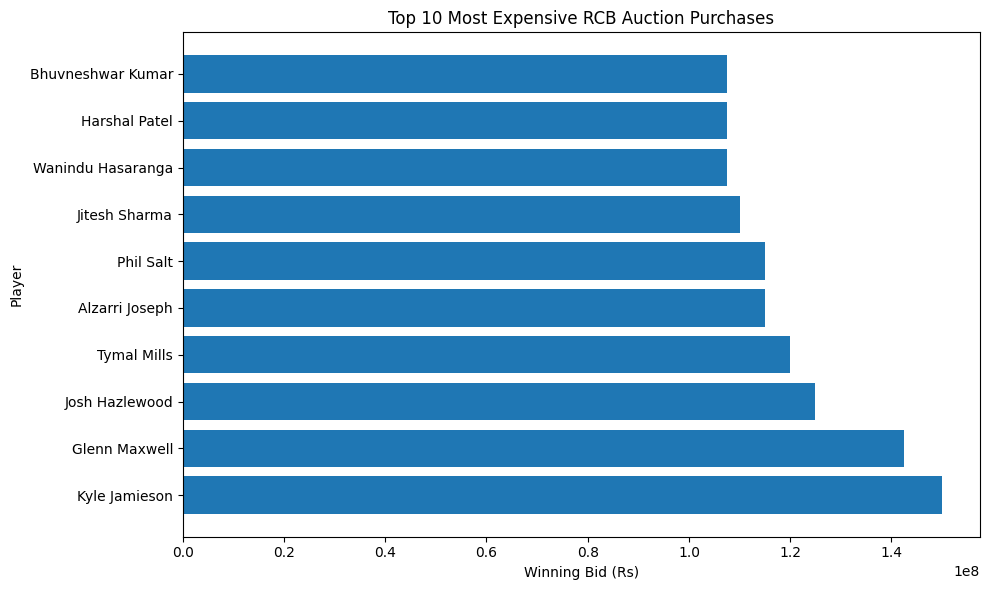

In [72]:
plt.figure(figsize=(10,6))

plt.barh(
    top_expensive["Name"],
    top_expensive["Winning Bid in Rs"]
)

plt.title("Top 10 Most Expensive RCB Auction Purchases")
plt.xlabel("Winning Bid (Rs)")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

##### 2) How much money did RCB spend in each auction?

In [73]:
auction_spending = (
    roi_summary
    .groupby("Auction_Year")["Winning Bid in Rs"]
    .sum()
    .reset_index()
)

auction_spending

,Auction_Year,Winning Bid in Rs
0,2016,154500000
1,2017,154000000
2,2018,488500000
3,2019,163500000
4,2020,215000000
5,2021,350500000
6,2022,554500000
7,2023,70000000
8,2024,204000000
9,2025,822500000


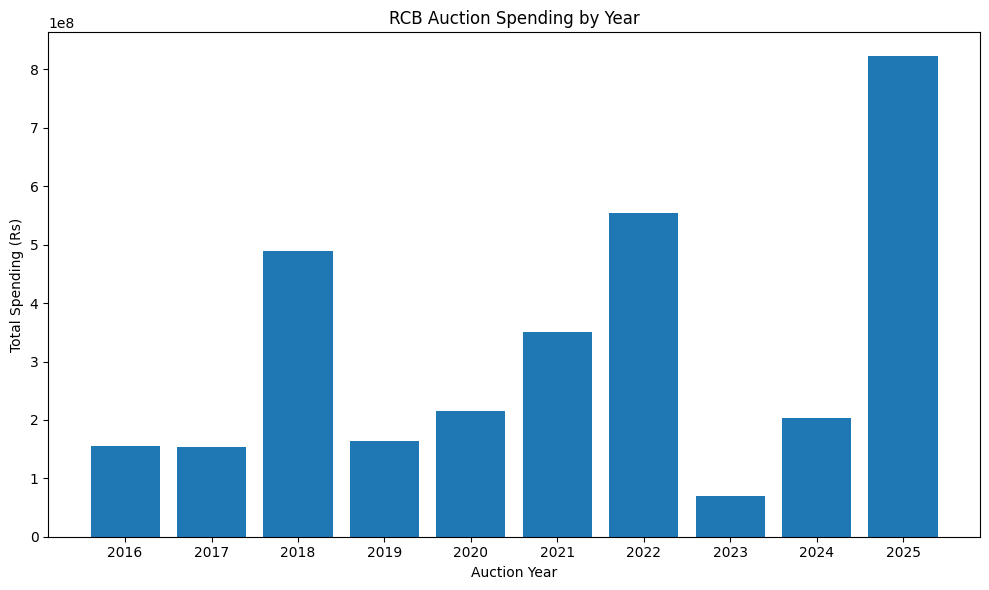

In [74]:
plt.figure(figsize=(10,6))

plt.bar(
    auction_spending["Auction_Year"].astype(str),
    auction_spending["Winning Bid in Rs"]
)

plt.title("RCB Auction Spending by Year")
plt.xlabel("Auction Year")
plt.ylabel("Total Spending (Rs)")

plt.tight_layout()
plt.show()

##### 3) How much did RCB spend on Indian vs Overseas players?

In [75]:
nationality_spending = (
    roi_summary
    .groupby("Nationality")["Winning Bid in Rs"]
    .sum()
    .reset_index()
)

nationality_spending

,Nationality,Winning Bid in Rs
0,Indian,720000000
1,Overseas,931000000


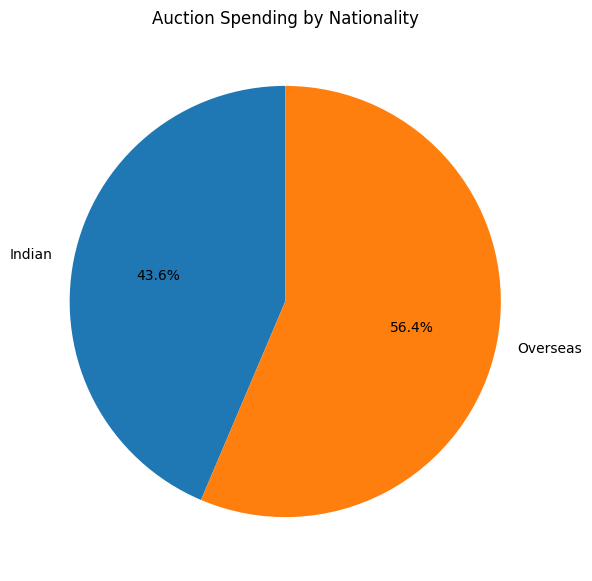

In [76]:
plt.figure(figsize=(7,7))

plt.pie(
    nationality_spending["Winning Bid in Rs"],
    labels=nationality_spending["Nationality"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Auction Spending by Nationality")

plt.show()

##### 4) Which player role received the highest investment?

In [77]:
role_spending = (
    roi_summary
    .groupby("Role")["Winning Bid in Rs"]
    .sum()
    .reset_index()
)

role_spending

,Role,Winning Bid in Rs
0,All-Rounder,1166500000
1,Batsman,263500000
2,Bowler,775500000
3,Wicket Keeper,149000000


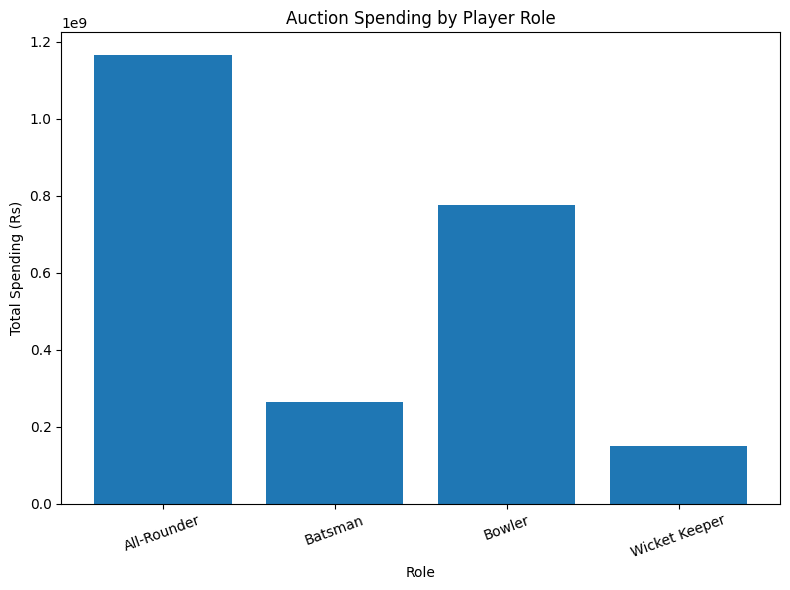

In [78]:
plt.figure(figsize=(8,6))

plt.bar(
    role_spending["Role"],
    role_spending["Winning Bid in Rs"]
)

plt.title("Auction Spending by Player Role")
plt.xlabel("Role")
plt.ylabel("Total Spending (Rs)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


#
# ==========================================================
# AUCTION SPENDING ANALYSIS
# ==========================================================

##### 1) Which players scored the most runs for RCB after being bought at auction?

In [79]:
top_runs = (
    roi_summary
    .sort_values("RCB_Runs", ascending=False)
    .head(10)
)

display(top_runs[
    ["Name", "RCB_Runs", "RCB_Matches"]
])

,Name,RCB_Runs,RCB_Matches
894,Faf du Plessis,1636,45
719,Glenn Maxwell,1266,51
605,Devdutt Padikkal,1131,39
722,Rajat Patidar,1111,38
897,KD Karthik,796,42
517,Parthiv Patel,526,20
1234,Phil Salt,403,13
903,Mahipal Lomror,346,27
662,Shahbaz Ahmed,321,34
900,Anuj Rawat,318,20


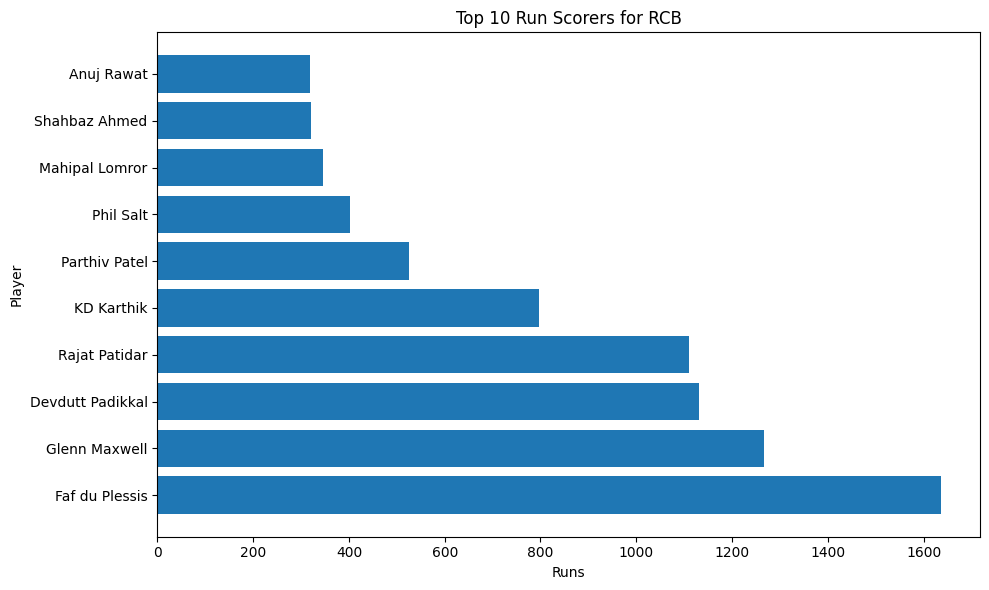

In [80]:
plt.figure(figsize=(10,6))

plt.barh(
    top_runs["Name"],
    top_runs["RCB_Runs"]
)

plt.title("Top 10 Run Scorers for RCB")
plt.xlabel("Runs")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

##### 2) Which batters maintained the highest batting average? (Minimum 300 Runs)

In [81]:
top_average = (
    roi_summary[
        roi_summary["RCB_Runs"] >= 300
    ]
    .sort_values(
        "RCB_Batting_Average",
        ascending=False
    )
    .head(10)
)

display(top_average[
    ["Name", "RCB_Batting_Average", "RCB_Runs"]
])

,Name,RCB_Batting_Average,RCB_Runs
894,Faf du Plessis,38.85,1636
897,KD Karthik,34.30,796
1234,Phil Salt,33.58,403
722,Rajat Patidar,31.91,1111
605,Devdutt Padikkal,30.20,1131
517,Parthiv Patel,28.62,526
719,Glenn Maxwell,27.30,1266
900,Anuj Rawat,23.65,318
518,Moeen Ali,16.92,309
903,Mahipal Lomror,16.57,346


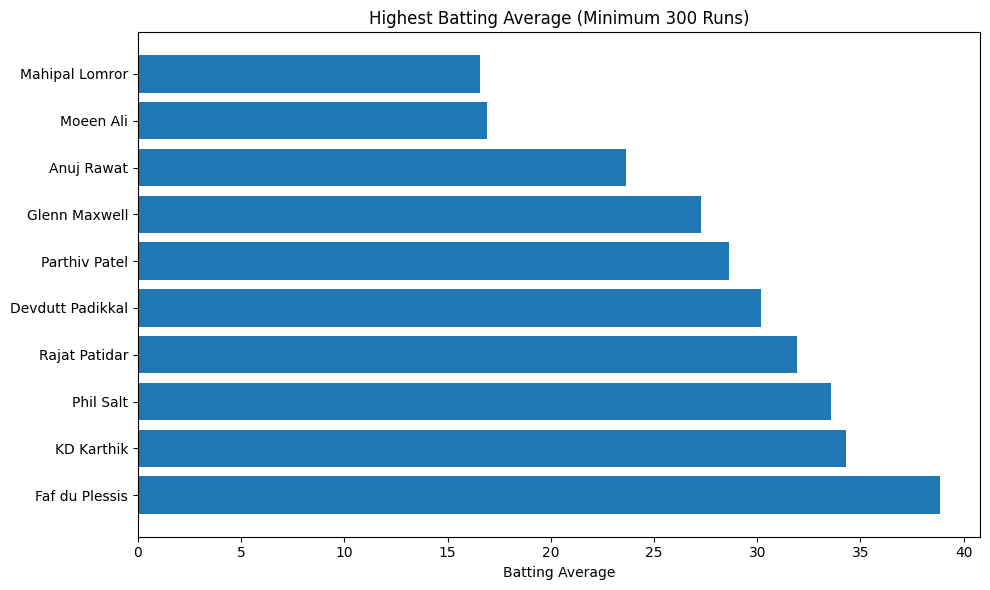

In [82]:
plt.figure(figsize=(10,6))

plt.barh(
    top_average["Name"],
    top_average["RCB_Batting_Average"]
)

plt.title("Highest Batting Average (Minimum 300 Runs)")
plt.xlabel("Batting Average")

plt.tight_layout()
plt.show()

##### 3) Highest Strike Rate (Minimum 300 Runs)

In [83]:
top_strike_rate = (
    roi_summary[
        roi_summary["RCB_Runs"] >= 300
    ]
    .sort_values(
        "RCB_Strike_Rate",
        ascending=False
    )
    .head(10)
)

display(top_strike_rate[
    ["Name", "RCB_Strike_Rate", "RCB_Runs"]
])

,Name,RCB_Strike_Rate,RCB_Runs
1234,Phil Salt,169.33,403
897,KD Karthik,162.78,796
518,Moeen Ali,155.28,309
719,Glenn Maxwell,152.90,1266
903,Mahipal Lomror,147.23,346
722,Rajat Patidar,146.38,1111
894,Faf du Plessis,144.01,1636
517,Parthiv Patel,137.70,526
605,Devdutt Padikkal,123.88,1131
900,Anuj Rawat,115.64,318


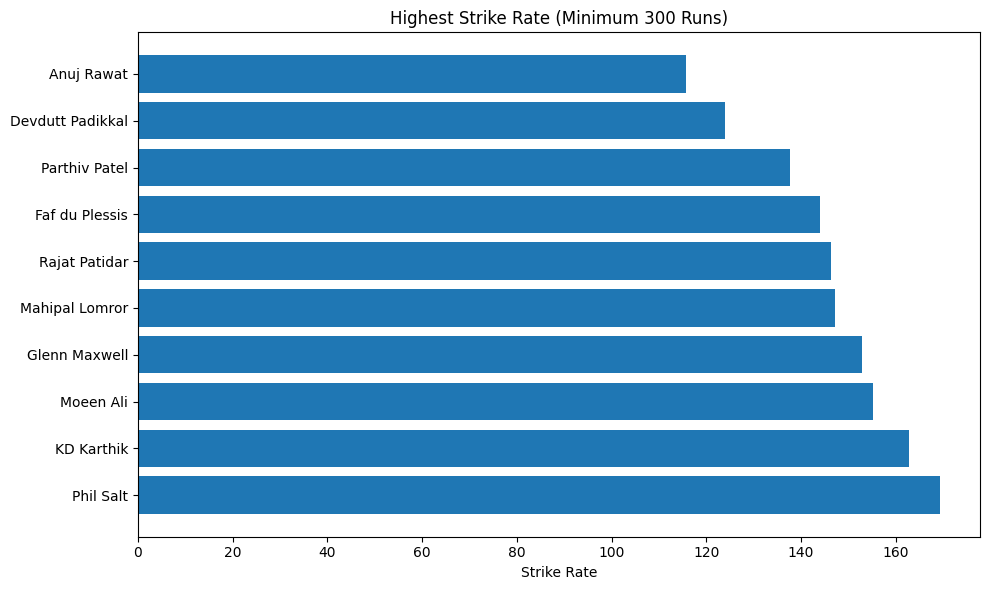

In [84]:
plt.figure(figsize=(10,6))

plt.barh(
    top_strike_rate["Name"],
    top_strike_rate["RCB_Strike_Rate"]
)

plt.title("Highest Strike Rate (Minimum 300 Runs)")
plt.xlabel("Strike Rate")

plt.tight_layout()
plt.show()

##### 4) Which batters provided the best value for money?

In [85]:
best_value_batters = (
    roi_summary[
        roi_summary["RCB_Runs"] >= 300
    ]
    .sort_values(
        "Cost_per_Run"
    )
    .head(10)
)

display(best_value_batters[
    [
        "Name",
        "Winning Bid in Rs",
        "RCB_Runs",
        "Cost_per_Run"
    ]
])

,Name,Winning Bid in Rs,RCB_Runs,Cost_per_Run
605,Devdutt Padikkal,2000000,1131,1768.346596
722,Rajat Patidar,2000000,1111,1800.180018
662,Shahbaz Ahmed,2000000,321,6230.529595
903,Mahipal Lomror,9500000,346,27456.647399
517,Parthiv Patel,17000000,526,32319.391635
894,Faf du Plessis,70000000,1636,42787.286064
518,Moeen Ali,17000000,309,55016.181230
897,KD Karthik,55000000,796,69095.477387
900,Anuj Rawat,34000000,318,106918.238994
719,Glenn Maxwell,142500000,1266,112559.241706


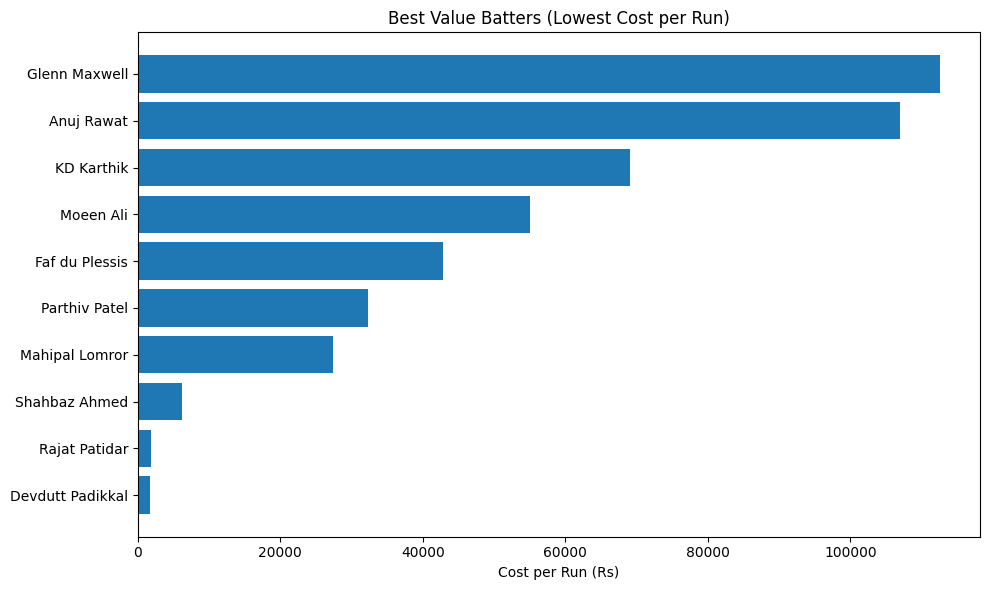

In [86]:
plt.figure(figsize=(10,6))

plt.barh(
    best_value_batters["Name"],
    best_value_batters["Cost_per_Run"]
)

plt.title("Best Value Batters (Lowest Cost per Run)")
plt.xlabel("Cost per Run (Rs)")

plt.tight_layout()
plt.show()

# 
# ==========================================================
# BOWLING PERFORMANCE ANALYSIS
# ==========================================================

##### 1) Which bowlers took the most wickets for RCB after being bought at auction?

In [87]:
top_wickets = (
    roi_summary
    .sort_values("RCB_Wickets", ascending=False)
    .head(10)
)

display(
    top_wickets[
        ["Name", "RCB_Wickets", "RCB_Matches"]
    ]
)

,Name,RCB_Wickets,RCB_Matches
513,Mohammed Siraj,84,87
507,Yuzvendra Chahal,69,58
898,Josh Hazlewood,45,27
896,Harshal Patel,33,28
508,Umesh Yadav,28,27
1078,Yash Dayal,28,29
294,Shane Watson,25,24
1233,Josh Hazlewood,22,12
370,Pawan Negi,20,17
510,Washington Sundar,19,31


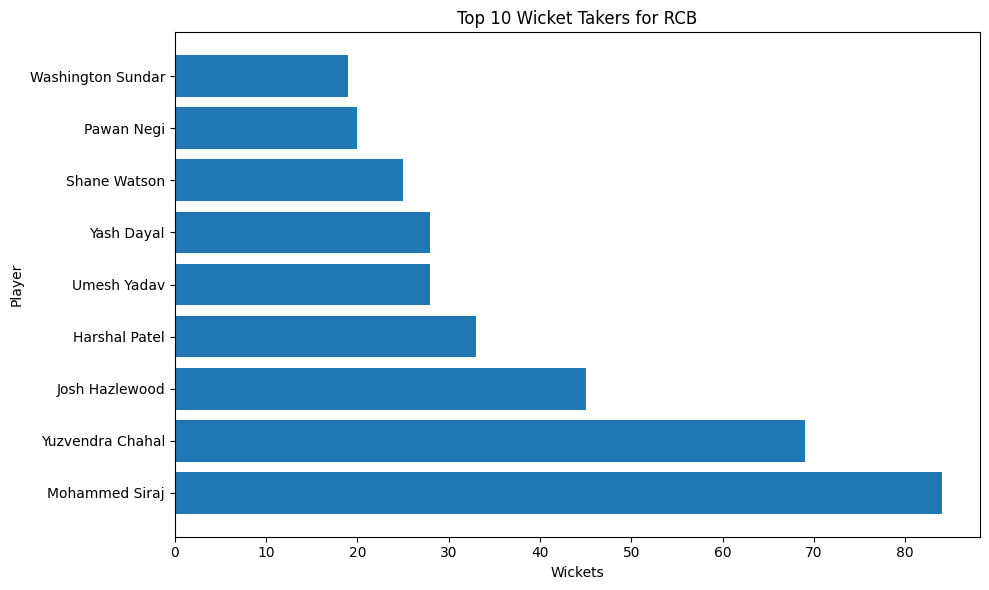

In [88]:
plt.figure(figsize=(10,6))

plt.barh(
    top_wickets["Name"],
    top_wickets["RCB_Wickets"]
)

plt.title("Top 10 Wicket Takers for RCB")
plt.xlabel("Wickets")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

##### 2) Which bowlers maintained the best economy rate?

In [89]:
best_economy = (
    roi_summary[
        roi_summary["RCB_Wickets"] >= 20
    ]
    .sort_values(
        "RCB_Economy"
    )
    .head(10)
)

display(
    best_economy[
        ["Name", "RCB_Economy", "RCB_Wickets"]
    ]
)

,Name,RCB_Economy,RCB_Wickets
370,Pawan Negi,6.42,20
507,Yuzvendra Chahal,6.90,69
513,Mohammed Siraj,7.63,84
896,Harshal Patel,7.66,33
898,Josh Hazlewood,7.99,45
294,Shane Watson,8.05,25
508,Umesh Yadav,8.24,28
1233,Josh Hazlewood,8.44,22
1078,Yash Dayal,8.51,28


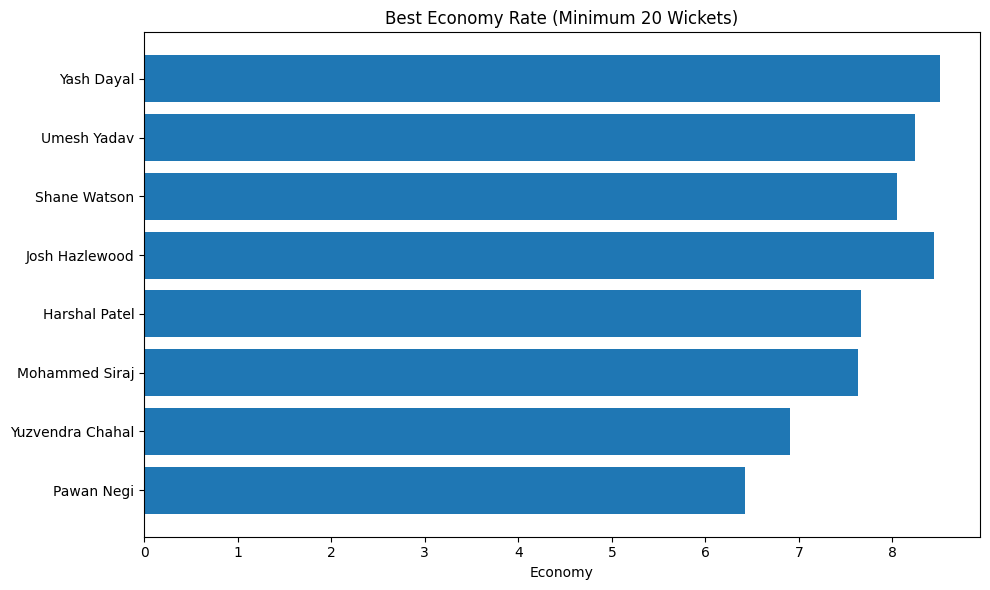

In [90]:
plt.figure(figsize=(10,6))

plt.barh(
    best_economy["Name"],
    best_economy["RCB_Economy"]
)

plt.title("Best Economy Rate (Minimum 20 Wickets)")
plt.xlabel("Economy")

plt.tight_layout()
plt.show()

##### 3) Best Value Bowlers (Lowest Cost per Wicket)

In [91]:
best_value_bowlers = (
    roi_summary[
        roi_summary["RCB_Wickets"] >= 20
    ]
    .sort_values(
        "Cost_per_Wicket"
    )
    .head(10)
)

display(
    best_value_bowlers[
        [
            "Name",
            "Winning Bid in Rs",
            "RCB_Wickets",
            "Cost_per_Wicket"
        ]
    ]
)

,Name,Winning Bid in Rs,RCB_Wickets,Cost_per_Wicket
513,Mohammed Siraj,26000000,84,3.095238e+05
370,Pawan Negi,10000000,20,5.000000e+05
507,Yuzvendra Chahal,60000000,69,8.695652e+05
508,Umesh Yadav,42000000,28,1.500000e+06
898,Josh Hazlewood,77500000,45,1.722222e+06
1078,Yash Dayal,50000000,28,1.785714e+06
896,Harshal Patel,107500000,33,3.257576e+06
294,Shane Watson,95000000,25,3.800000e+06
1233,Josh Hazlewood,125000000,22,5.681818e+06


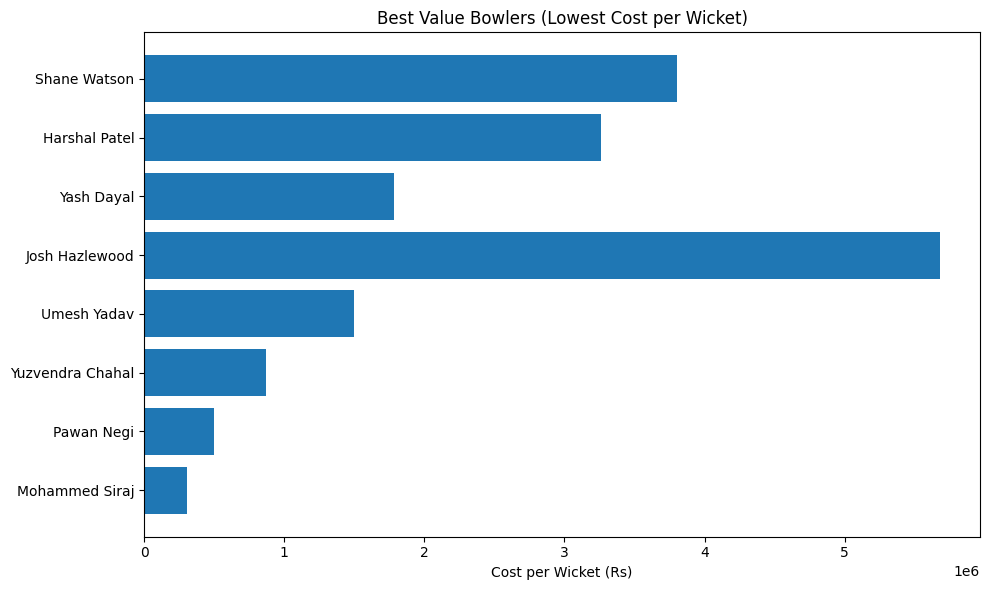

In [92]:
plt.figure(figsize=(10,6))

plt.barh(
    best_value_bowlers["Name"],
    best_value_bowlers["Cost_per_Wicket"]
)

plt.title("Best Value Bowlers (Lowest Cost per Wicket)")
plt.xlabel("Cost per Wicket (Rs)")

plt.tight_layout()
plt.show()

##### Did spending more money result in more wickets?

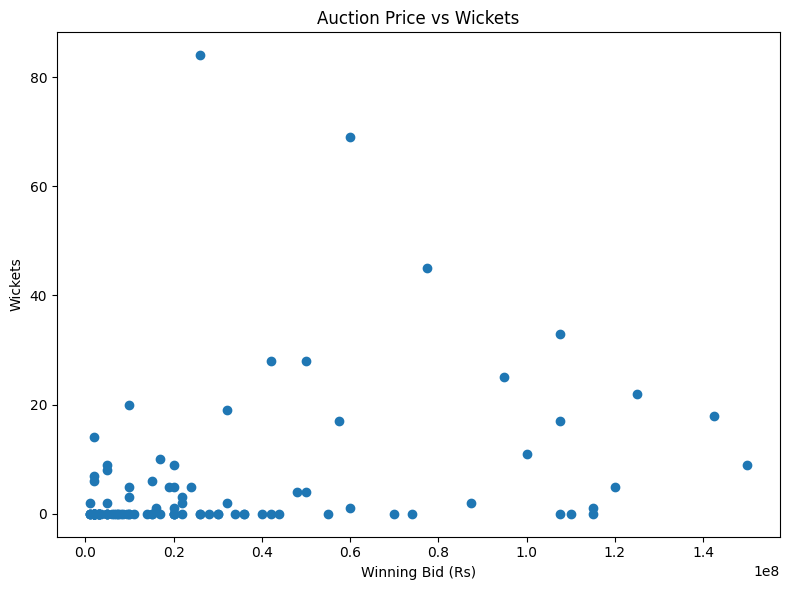

In [93]:
plt.figure(figsize=(8,6))

plt.scatter(
    roi_summary["Winning Bid in Rs"],
    roi_summary["RCB_Wickets"]
)

plt.title("Auction Price vs Wickets")
plt.xlabel("Winning Bid (Rs)")
plt.ylabel("Wickets")

plt.tight_layout()
plt.show()

### Key Observations

- A few bowlers accounted for the majority of RCB's wickets.
- Expensive bowling signings did not always produce the highest wicket returns.
- Several lower-priced bowlers delivered excellent value in terms of cost per wicket.
- Economy rate and wicket-taking ability were not always directly correlated.

#
# ==========================================================
# OVERALL ROI ANALYSIS
# ==========================================================

##### 1) Which auction signings served RCB the longest?

,Name,RCB_Matches
513,Mohammed Siraj,87
507,Yuzvendra Chahal,58
719,Glenn Maxwell,51
894,Faf du Plessis,45
897,KD Karthik,42
605,Devdutt Padikkal,39
722,Rajat Patidar,38
662,Shahbaz Ahmed,34
510,Washington Sundar,31
1078,Yash Dayal,29


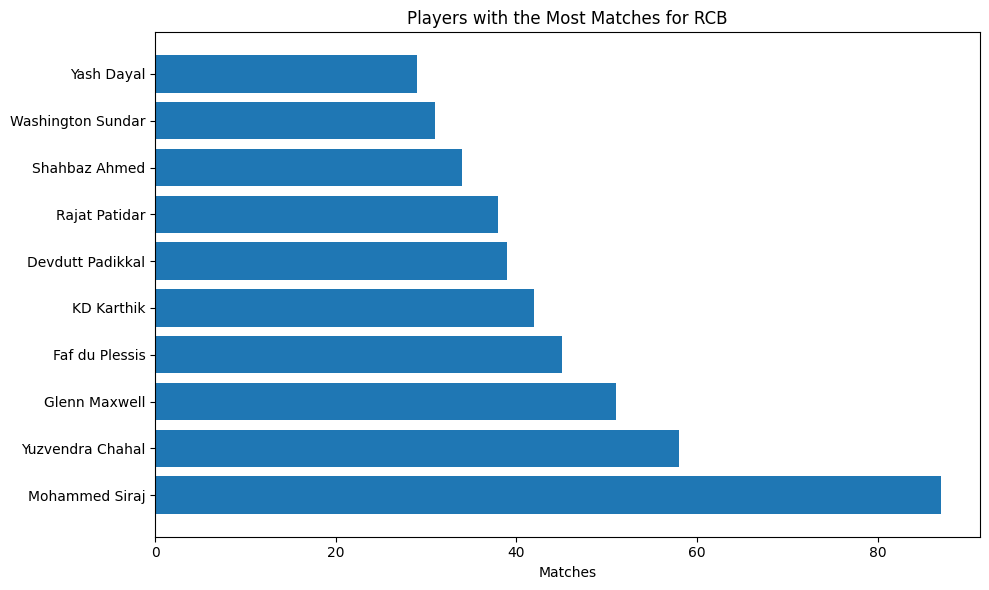

In [94]:
top_matches = (
    roi_summary
    .sort_values("RCB_Matches", ascending=False)
    .head(10)
)

display(
    top_matches[
        ["Name","RCB_Matches"]
    ]
)
plt.figure(figsize=(10,6))

plt.barh(
    top_matches["Name"],
    top_matches["RCB_Matches"]
)

plt.title("Players with the Most Matches for RCB")
plt.xlabel("Matches")
plt.tight_layout()
plt.show()

##### 2) Most Expensive Underperforming Signings

In [95]:
expensive_flops = (
    roi_summary[
        (roi_summary["Winning Bid in Rs"] >= 50000000) &
        (roi_summary["RCB_Runs"] < 300) &
        (roi_summary["RCB_Wickets"] < 20)
    ]
    .sort_values(
        "Winning Bid in Rs",
        ascending=False
    )
)

display(
    expensive_flops[
        [
            "Name",
            "Winning Bid in Rs",
            "RCB_Runs",
            "RCB_Wickets"
        ]
    ]
)

,Name,Winning Bid in Rs,RCB_Runs,RCB_Wickets
718,Kyle Jamieson,150000000,65,9
368,Tymal Mills,120000000,8,5
1076,Alzarri Joseph,115000000,0,1
1235,Jitesh Sharma,110000000,261,0
1236,Bhuvneshwar Kumar,107500000,14,17
895,Wanindu Hasaranga,107500000,0,0
657,Chris Morris,100000000,34,11
1237,Liam Livingstone,87500000,112,2
506,Chris Woakes,74000000,0,0
1238,Rasikh Salam,60000000,0,1


##### 3) Overall Contribution

In [96]:
overall = roi_summary.sort_values(
    "RCB_Matches",
    ascending=False
)

display(
    overall[
        [
            "Name",
            "RCB_Matches",
            "RCB_Runs",
            "RCB_Wickets"
        ]
    ].head(10)
)

,Name,RCB_Matches,RCB_Runs,RCB_Wickets
513,Mohammed Siraj,87,109,84
507,Yuzvendra Chahal,58,17,69
719,Glenn Maxwell,51,1266,18
894,Faf du Plessis,45,1636,0
897,KD Karthik,42,796,0
605,Devdutt Padikkal,39,1131,0
722,Rajat Patidar,38,1111,0
662,Shahbaz Ahmed,34,321,14
510,Washington Sundar,31,208,19
1078,Yash Dayal,29,4,28


# ==========================================================
# KEY INSIGHTS & CONCLUSION
# ==========================================================

## Key Insights

- This project combined IPL auction data with season-wise player performance to evaluate the effectiveness of RCB's auction purchases between 2016 and 2025.
- Auction expenditure varied significantly across different auction years, with mega auctions requiring substantially higher investments than regular auctions.
- Higher auction prices did not consistently result in better on-field performance, highlighting the uncertainty involved in player auctions.
- Several relatively inexpensive players delivered excellent value for money through consistent batting or bowling performances.
- Cost per Run and Cost per Wicket provided a more meaningful measure of player value than auction price alone.
- Analysing batting and bowling performances separately helped identify specialists who delivered strong returns despite modest auction prices.
- Comparing player performance across multiple seasons offered a more reliable assessment of long-term contribution than evaluating a single season.
- The ROI framework developed in this project can be applied to future IPL auctions or extended to analyse other franchises.

## Conclusion

This project demonstrates how auction data can be transformed into meaningful business insights by integrating it with player performance statistics. Instead of evaluating players solely on traditional cricket metrics, the analysis introduced ROI-based measures such as Cost per Run and Cost per Wicket to assess the financial efficiency of RCB's auction strategy.

The results show that auction price alone is not a reliable indicator of future success. While some high-value purchases justified their price through consistent performances, several lower-cost signings generated excellent returns relative to their investment. Overall, this project highlights the importance of combining financial and performance data to support better decision-making in sports analytics.

## Filling Missing Nationality Values

In [97]:
nationality_mapping = {
    # 2016
    "Shane Watson": "Overseas",
    "Stuart Binny": "Indian",
    "Kane Richardson": "Overseas",
    "Samuel Badree": "Overseas",
    "Travis Head": "Overseas",
    "Praveen Dubey": "Indian",
    "Vikramjeet Malik": "Indian",
    "Akshay Karnewar": "Indian",
    "Iqbal Abdulla": "Indian",
    "Sachin Baby": "Indian",
    "Vikas Tokas": "Indian",

    # 2017
    "Tymal Mills": "Overseas",
    "Aniket Choudhary": "Indian",
    "Pawan Negi": "Indian",
    "Billy Stanlake": "Overseas",

    # 2018
    "Chris Woakes": "Overseas",
    "Yuzvendra Chahal": "Indian",
    "Umesh Yadav": "Indian",
    "Brendon McCullum": "Overseas",
    "Washington Sundar": "Indian",
    "Navdeep Saini": "Indian",
    "Quinton de Kock": "Overseas",
    "Mohammed Siraj": "Indian",
    "Nathan Coulter-Nile": "Overseas",
    "Colin de Grandhomme": "Overseas",
    "Murugan Ashwin": "Indian",
    "Parthiv Patel": "Indian",
    "Moeen Ali": "Overseas",
    "Mandeep Singh": "Indian",
    "Manan Vohra": "Indian",
    "Tim Southee": "Overseas",
    "Kulwant Khejroliya": "Indian",
    "Pavan Deshpande": "Indian",
    "Anirudha Ashok Joshi": "Indian",

    # 2019
    "Shivam Dube": "Indian",
    "Shimron Hetmyer": "Overseas",
    "Akshdeep Nath": "Indian",
    "Prayas Ray Barman": "Indian",
    "Himmat Singh": "Indian",
    "Gurkeerat Mann Singh": "Indian",
    "Heinrich Klaasen": "Overseas",
    "Devdutt Padikkal": "Indian",
    "Milind Kumar": "Indian",

    # 2020
    "Chris Morris": "Overseas",
    "Aaron Finch": "Overseas",
    "Dale Steyn": "Overseas",
    "I Udana": "Overseas",
    "Shahbaz Ahmed": "Indian",
    "JR Philippe": "Overseas",

    # 2021
    "Kyle Jamieson": "Overseas",
    "Glenn Maxwell": "Overseas",
    "Dan Christian": "Overseas",
    "Rajat Patidar": "Indian",
    "Mohammed Azharuddeen": "Indian",
    "K.S Bharat": "Indian",
    "Iqbal Abdullah" : "Indian",
    "Mohammed Azharudeen": "Indian" ,
    "Suyash S Prabhudessai": "Indian",
}

In [98]:
roi_summary["Nationality"] = (
    roi_summary["Nationality"]
    .replace("nan", pd.NA)
    .fillna(roi_summary["Name"].map(nationality_mapping))
)

### Validate Nationality Distribution

In [99]:
roi_summary["Nationality"].value_counts(dropna=False)

Nationality
Indian      68
Overseas    45
Name: count, dtype: int64

## Filling Missing Player Roles

In [100]:
role_mapping = {
    "Josh Hazlewood": "Bowler",
    "Phil Salt": "Wicket Keeper",
    "Jitesh Sharma": "Wicket Keeper",
    "Bhuvneshwar Kumar": "Bowler",
    "Liam Livingstone": "All-Rounder",
    "Rasikh Salam": "Bowler",
    "Krunal Pandya": "All-Rounder",
    "Tim David": "All-Rounder",
    "JG Bethell": "All-Rounder",
    "Suyash Sharma": "Bowler",
    "Devdutt Padikkal": "Batsman",
    "Nuwan Thushara": "Bowler",
    "Romario Shepherd": "All-Rounder",
    "Lungisani Ngidi": "Bowler",
    "Swapnil Singh": "All-Rounder",
    "Mohit Rathee": "All-Rounder",
    "Abhinandan Singh": "Bowler",
    "Swastik Chhikara": "Batsman",
    "Manoj Bhandage": "All-Rounder"
}

roi_summary["Role"] = (
    roi_summary["Role"]
    .replace("nan", pd.NA)
    .fillna(roi_summary["Name"].map(role_mapping))
)

### Validate Role Distribution

In [101]:
roi_summary["Role"].value_counts(dropna=False)

Role
All-Rounder      47
Bowler           38
Batsman          16
Wicket Keeper    12
Name: count, dtype: int64


# ==========================================================
# EXPORT FINAL ROI DATASET
# ==========================================================

In [ ]:
roi_summary.to_csv("Data/RCB_ROI_Summary.csv", index=False)